In [3]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv(r"C:\AIR_QUALITY_INDEX\city_day.csv")

In [6]:
print(df.shape)

(29531, 16)


In [7]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 4.3 MB


In [9]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [10]:
df.dtypes

City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

In [11]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [12]:
print("\n Duplicate Rows: ", df.duplicated().sum())


 Duplicate Rows:  0


In [13]:
print("\nNumber of Cities:", df['City'].nunique())
print("\nCities:")
print(df['City'].unique())



Number of Cities: 26

Cities:
<ArrowStringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str


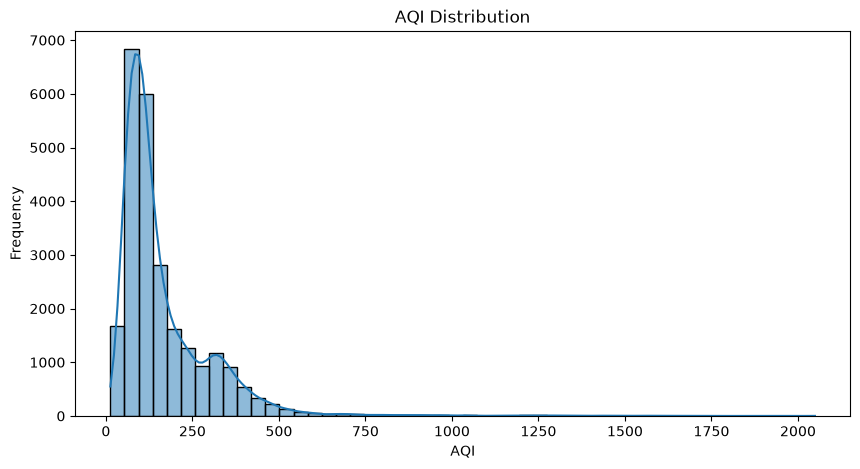

In [14]:
#AQI DISTRIBUTION
plt.figure(figsize=(10, 5))

sns.histplot(df['AQI'].dropna(), bins=50, kde=True)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

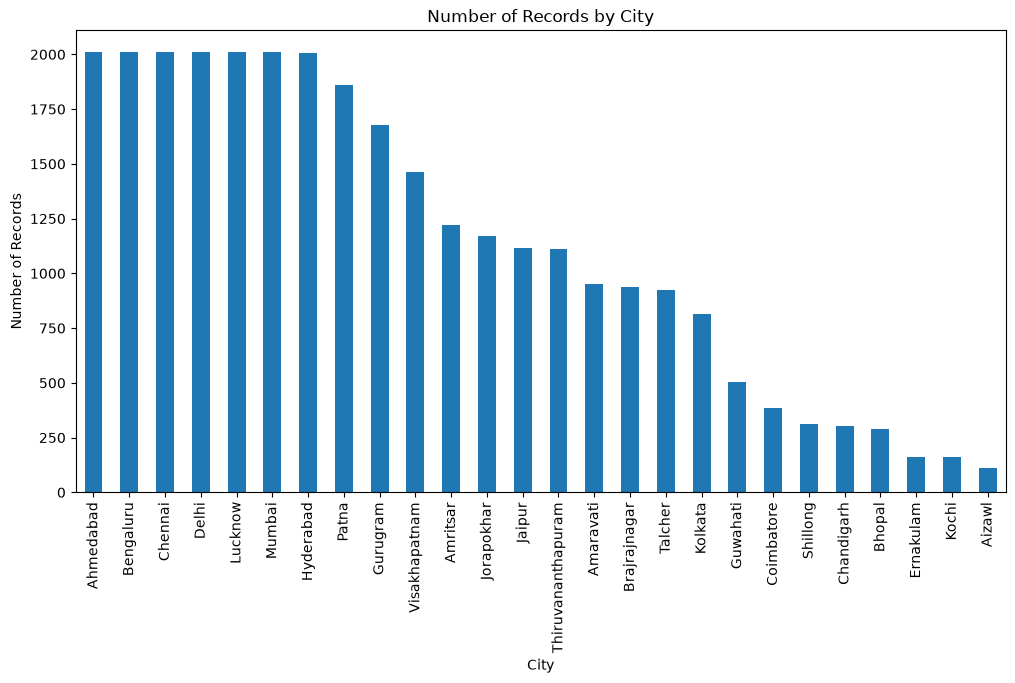

In [15]:

plt.figure(figsize=(12, 6))

df['City'].value_counts().plot(kind='bar')

plt.title("Number of Records by City")
plt.xlabel("City")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.show()

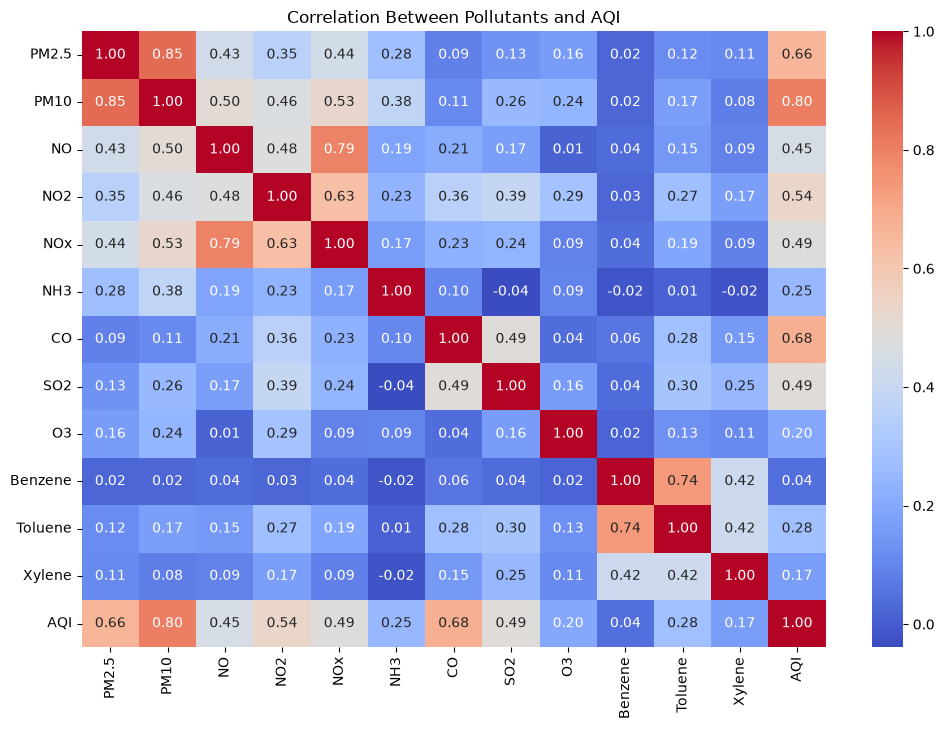

In [16]:
pollutants = ['PM2.5','PM10','NO',
'NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']
pollutants_with_aqi = pollutants + ['AQI']

correlation = df[pollutants_with_aqi].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Pollutants and AQI")
plt.show()

In [17]:
df_model = df.dropna(subset=['AQI']).copy()

print("Original shape:", df.shape)
print("After removing missing AQI:", df_model.shape)

Original shape: (29531, 16)
After removing missing AQI: (24850, 16)


In [18]:
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2', 'O3','Benzene','Toluene','Xylene']

X = df_model[pollutants]
y = df_model['AQI']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (24850, 12)
y shape: (24850,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (19880, 12)
Testing data: (4970, 12)


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [21]:
#train the model
linear_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['PM2.5','PM10','NO',...,'Benzene','Toluene','Xylene']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy co

In [22]:
#predict
y_pred = linear_pipeline.predict(X_test)

In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 31.169817669215988
MSE : 3533.0732299739448
RMSE: 59.4396604126735
R²  : 0.807052091808218


In [24]:
results = []

results.append({
    'Model': 'Linear Regression',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2
})

import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

               Model        MAE         MSE      RMSE        R2
0  Linear Regression  31.169818  3533.07323  59.43966  0.807052


In [25]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

knn_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

In [26]:
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['PM2.5','PM10','NO',...,'Benzene','Toluene','Xylene']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy co

In [27]:
y_pred_knn = knn_pipeline.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = mse_knn ** 0.5
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression Results")
print("----------------------")
print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE:", rmse_knn)
print("R²  :", r2_knn)

KNN Regression Results
----------------------
MAE : 24.110140845070422
MSE : 2297.8191951710264
RMSE: 47.93557337897427
R²  : 0.8745116847990034


In [29]:
results.append({
    'Model': 'KNN Regression',
    'MAE': mae_knn,
    'MSE': mse_knn,
    'RMSE': rmse_knn,
    'R2': r2_knn
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,31.169818,3533.073230,59.439660,0.807052
1,KNN Regression,24.110141,2297.819195,47.935573,0.874512


In [30]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeRegressor(random_state=42))
])

In [31]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['PM2.5','PM10','NO',...,'Benzene','Toluene','Xylene']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bo

In [32]:
y_pred_dt = dt_pipeline.predict(X_test)

In [33]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Results")
print("--------------------------------")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Regression Results
--------------------------------
MAE : 29.319266953069768
MSE : 3211.757256467953
RMSE: 56.67236766245039
R²  : 0.8245997736481001


In [34]:
results.append({
    'Model': 'Decision Tree',
    'MAE': mae_dt,
    'MSE': mse_dt,
    'RMSE': rmse_dt,
    'R2': r2_dt
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,31.169818,3533.073230,59.439660,0.807052
1,KNN Regression,24.110141,2297.819195,47.935573,0.874512
2,Decision Tree,29.319267,3211.757256,56.672368,0.824600


In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [36]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['PM2.5','PM10','NO',...,'Benzene','Toluene','Xylene']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bo

In [37]:
y_pred_rf = rf_pipeline.predict(X_test)

In [38]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
--------------------------------
MAE : 20.835860174003365
MSE : 1684.1278124928078
RMSE: 41.038126327755364
R²  : 0.90802654873064


In [39]:
results.append({
    'Model': 'Random Forest',
    'MAE': mae_rf,
    'MSE': mse_rf,
    'RMSE': rmse_rf,
    'R2': r2_rf
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,31.169818,3533.073230,59.439660,0.807052
1,KNN Regression,24.110141,2297.819195,47.935573,0.874512
2,Decision Tree,29.319267,3211.757256,56.672368,0.824600
3,Random Forest,20.835860,1684.127812,41.038126,0.908027


In [40]:
from sklearn.ensemble import AdaBoostRegressor

adaboost_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', AdaBoostRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [41]:
adaboost_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['PM2.5','PM10','NO',...,'Benzene','Toluene','Xylene']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bo

In [42]:
y_pred_ada = adaboost_pipeline.predict(X_test)

In [43]:
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = mse_ada ** 0.5
r2_ada = r2_score(y_test, y_pred_ada)

print("AdaBoost Regression Results")
print("---------------------------")
print("MAE :", mae_ada)
print("MSE :", mse_ada)
print("RMSE:", rmse_ada)
print("R²  :", r2_ada)

AdaBoost Regression Results
---------------------------
MAE : 198.3993448199926
MSE : 44392.93176017651
RMSE: 210.6963021986302
R²  : -1.4243831825953253


In [44]:
results.append({
    'Model': 'AdaBoost',
    'MAE': mae_ada,
    'MSE': mse_ada,
    'RMSE': rmse_ada,
    'R2': r2_ada
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,31.169818,3533.073230,59.439660,0.807052
1,KNN Regression,24.110141,2297.819195,47.935573,0.874512
2,Decision Tree,29.319267,3211.757256,56.672368,0.824600
3,Random Forest,20.835860,1684.127812,41.038126,0.908027
4,AdaBoost,198.399345,44392.931760,210.696302,-1.424383


In [45]:
from sklearn.svm import SVR

svr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf'))
])

In [46]:
svr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['PM2.5','PM10','NO',...,'Benzene','Toluene','Xylene']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy co

In [47]:
y_pred_svr = svr_pipeline.predict(X_test)

In [48]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = mse_svr ** 0.5
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Regression Results")
print("----------------------")
print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE:", rmse_svr)
print("R²  :", r2_svr)

SVR Regression Results
----------------------
MAE : 34.07195077569125
MSE : 6264.3939209593855
RMSE: 79.14792429975272
R²  : 0.6578894281375136


In [49]:
results.append({
    'Model': 'SVR',
    'MAE': mae_svr,
    'MSE': mse_svr,
    'RMSE': rmse_svr,
    'R2': r2_svr
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,31.169818,3533.073230,59.439660,0.807052
1,KNN Regression,24.110141,2297.819195,47.935573,0.874512
2,Decision Tree,29.319267,3211.757256,56.672368,0.824600
3,Random Forest,20.835860,1684.127812,41.038126,0.908027
4,AdaBoost,198.399345,44392.931760,210.696302,-1.424383
5,SVR,34.071951,6264.393921,79.147924,0.657889


Interpretation:

Random Forest is clearly the best baseline model with the lowest MAE/RMSE and highest R².
KNN is the second-best model.
Decision Tree performs reasonably well but is weaker than Random Forest.
Linear Regression provides a useful simple baseline.
SVR performs considerably worse on this dataset with the current parameters.
AdaBoost performs extremely poorly, giving a negative R². We should keep this result rather than remove it, because it is an important experimental finding.

Can hyperparameter optimization improve the performance of the best baseline Random Forest model?

In [50]:
from sklearn.model_selection import GridSearchCV

In [51]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

In [52]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [53]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

In [54]:
rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple me

In [55]:
print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [56]:
print("Best CV RMSE:")
print(-rf_grid.best_score_)

Best CV RMSE:
43.93876734757975


Evaluate the tuned model on our test set

In [57]:
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = mse_rf_tuned ** 0.5
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Results")
print("MAE :", mae_rf_tuned)
print("MSE :", mse_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R²  :", r2_rf_tuned)

Tuned Random Forest Results
MAE : 20.763138876497635
MSE : 1680.971779305367
RMSE: 40.99965584374297
R²  : 0.9081989057586615


baseline Random Forest :R² = 0.9080
After GridSearchCV:R² = 0.9082

In [59]:
from sklearn.model_selection import GridSearchCV

knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exampl

In [60]:
print("Best Parameters:")
print(knn_grid.best_params_)

print("\nBest CV RMSE:")
print(-knn_grid.best_score_)

Best Parameters:
{'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'distance'}

Best CV RMSE:
46.83264300816612


In [61]:
best_knn = knn_grid.best_estimator_

y_pred_knn_tuned = best_knn.predict(X_test)

mae_knn_tuned = mean_absolute_error(y_test, y_pred_knn_tuned)
mse_knn_tuned = mean_squared_error(y_test, y_pred_knn_tuned)
rmse_knn_tuned = mse_knn_tuned ** 0.5
r2_knn_tuned = r2_score(y_test, y_pred_knn_tuned)

print("Tuned KNN Results")
print("MAE :", mae_knn_tuned)
print("MSE :", mse_knn_tuned)
print("RMSE:", rmse_knn_tuned)
print("R²  :", r2_knn_tuned)

Tuned KNN Results
MAE : 22.74687002986326
MSE : 1992.6946707971113
RMSE: 44.63960876617436
R²  : 0.8911751205343543


The improvement in R² from 0.8745 → 0.8912 
Hyperparameter tuning improved both Random Forest and KNN, but Random Forest continued to provide the strongest predictive performance.

In [62]:
#tuned decision tree
dt_param_grid = {
    'model__max_depth': [None, 5, 10, 15, 20, 25],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`s

In [63]:
print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest CV RMSE:")
print(-dt_grid.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Best CV RMSE:
51.139299660495205


In [64]:
best_dt = dt_grid.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)

mae_dt_tuned = mean_absolute_error(y_test, y_pred_dt_tuned)
mse_dt_tuned = mean_squared_error(y_test, y_pred_dt_tuned)
rmse_dt_tuned = mse_dt_tuned ** 0.5
r2_dt_tuned = r2_score(y_test, y_pred_dt_tuned)

print("Tuned Decision Tree Results")
print("MAE :", mae_dt_tuned)
print("MSE :", mse_dt_tuned)
print("RMSE:", rmse_dt_tuned)
print("R²  :", r2_dt_tuned)

Tuned Decision Tree Results
MAE : 24.53573804514496
MSE : 2266.0495436801098
RMSE: 47.60304132805077
R²  : 0.8762466864251088


The R² improvement from 0.8246 → 0.8762

In [65]:
svr_param_grid = {
    'model__C': [1, 10, 100],
    'model__gamma': ['scale', 'auto'],
    'model__epsilon': [0.1, 0.5]
}

svr_grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

svr_grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [1, 10, ...], 'model__epsilon': [0.1, 0.5], 'model__gamma': ['scale', 'auto']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_mo

In [66]:
best_svr = svr_grid.best_estimator_

y_pred_svr_tuned = best_svr.predict(X_test)

mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)
mse_svr_tuned = mean_squared_error(y_test, y_pred_svr_tuned)
rmse_svr_tuned = mse_svr_tuned ** 0.5
r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)

print("Best Parameters:")
print(svr_grid.best_params_)

print("\nTuned SVR Results")
print("MAE :", mae_svr_tuned)
print("MSE :", mse_svr_tuned)
print("RMSE:", rmse_svr_tuned)
print("R²  :", r2_svr_tuned)

Best Parameters:
{'model__C': 100, 'model__epsilon': 0.5, 'model__gamma': 'scale'}

Tuned SVR Results
MAE : 22.478822047582955
MSE : 2463.625822330531
RMSE: 49.63492542888053
R²  : 0.865456666747482


Experiment 2: Pollutants + City → AQI.

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

numeric_features = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
    'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene'
]

categorical_features = ['City']

X_city = df_model[numeric_features + categorical_features]
y_city = df_model['AQI']

In [68]:
from sklearn.model_selection import train_test_split

X_train_city, X_test_city, y_train_city, y_test_city = train_test_split(
    X_city,
    y_city,
    test_size=0.20,
    random_state=42
)

In [69]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [70]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [71]:
rf_city_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [72]:
rf_city_pipeline.fit(X_train_city, y_train_city)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['PM2.5','PM10','NO',...,'Toluene','Xylene','City']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with

In [73]:
y_pred_city = rf_city_pipeline.predict(X_test_city)

mae_city = mean_absolute_error(y_test_city, y_pred_city)
mse_city = mean_squared_error(y_test_city, y_pred_city)
rmse_city = mse_city ** 0.5
r2_city = r2_score(y_test_city, y_pred_city)

print("Random Forest - Pollutants + City")
print("MAE :", mae_city)
print("MSE :", mse_city)
print("RMSE:", rmse_city)
print("R²  :", r2_city)

Random Forest - Pollutants + City
MAE : 20.43446865159209
MSE : 1630.0264472219058
RMSE: 40.373586008947804
R²  : 0.9109811280953641


“Incorporating geographical information through the City feature improved Random Forest performance. The R² score increased from 0.9082 to 0.9110, while RMSE decreased from 40.9997 to 40.3736. This indicates that geographical differences between Indian cities provide additional information useful for AQI prediction.

In [74]:
rf_city_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

In [75]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [76]:
rf_city_grid = GridSearchCV(
    estimator=rf_city_pipeline,
    param_grid=rf_city_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_city_grid.fit(X_train_city, y_train_city)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 20], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metrice

In [77]:
print("Best Parameters:")
print(rf_city_grid.best_params_)

print("\nBest CV RMSE:")
print(-rf_city_grid.best_score_)

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best CV RMSE:
43.592946433125576


In [78]:
best_rf_city = rf_city_grid.best_estimator_

y_pred_rf_city_tuned = best_rf_city.predict(X_test_city)

mae_rf_city_tuned = mean_absolute_error(y_test_city, y_pred_rf_city_tuned)
mse_rf_city_tuned = mean_squared_error(y_test_city, y_pred_rf_city_tuned)
rmse_rf_city_tuned = mse_rf_city_tuned ** 0.5
r2_rf_city_tuned = r2_score(y_test_city, y_pred_rf_city_tuned)

print("Tuned Random Forest - Pollutants + City")
print("MAE :", mae_rf_city_tuned)
print("MSE :", mse_rf_city_tuned)
print("RMSE:", rmse_rf_city_tuned)
print("R²  :", r2_rf_city_tuned)

Tuned Random Forest - Pollutants + City
MAE : 20.495067119535488
MSE : 1658.1145571336285
RMSE: 40.71995281349953
R²  : 0.9094471825188758


tuning the City-based Random Forest actually made it slightly worse than the untuned version.

Best model : rf +pollutants + city(untuned)

Adding City information improved AQI prediction, while the selected hyperparameter tuning configuration did not improve the City-based model.

In [79]:
import sys

print(sys.executable)

c:\AIR_QUALITY_INDEX\.venv\Scripts\python.exe


In [80]:
%pip install -q mlflow

Note: you may need to restart the kernel to use updated packages.


In [81]:
import mlflow
import mlflow.sklearn

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [82]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("AQI Prediction - ML Experiments")

print("MLflow experiment created successfully!")

MLflow experiment created successfully!


In [83]:
mlflow.sklearn.autolog()


Random Forest + City experiment in MLflow.

In [84]:
with mlflow.start_run(run_name="Random Forest + City"):

    # Train
    rf_city_pipeline.fit(X_train_city, y_train_city)

    # Predict
    y_pred = rf_city_pipeline.predict(X_test_city)

    # Metrics
    mae = mean_absolute_error(y_test_city, y_pred)
    mse = mean_squared_error(y_test_city, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test_city, y_pred)

    # Print results
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

    # Additional tags
    mlflow.set_tag("feature_set", "Pollutants + City")
    mlflow.set_tag("model_type", "Random Forest")

print("MLflow run completed!")

2026/09/13 00:30:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MAE : 20.43446865159209
MSE : 1630.0264472219058
RMSE: 40.373586008947804
R²  : 0.9109811280953641
MLflow run completed!


In [85]:
runs = mlflow.search_runs(
    experiment_names=["AQI Prediction - ML Experiments"]
)

runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.training_root_mean_squared_error,metrics.training_score,metrics.training_mean_squared_error,metrics.training_r2_score,...,tags.estimator_name,tags.mlflow.source.name,tags.mlflow.source.type,tags.estimator_class,tags.model_type,tags.mlflow.runName,tags.mlflow.user,tags.dataset,tags.features,tags.model
0,68c415913b4444518e3df51e7df2b234,1,FINISHED,file:///c:/AIR_QUALITY_INDEX/mlruns/1/68c41591...,2026-09-12 19:00:37.573000+00:00,2026-09-12 19:00:51.426000+00:00,16.80425,0.985996,282.38283,0.985996,...,Pipeline,airquality.ipynb,NOTEBOOK,sklearn.pipeline.Pipeline,Random Forest,Random Forest + City,LENOVO,NaN,NaN,NaN
1,52f5d380195f42fc8b23eea465448d57,1,FINISHED,file:///c:/AIR_QUALITY_INDEX/mlruns/1/52f5d380...,2026-09-12 15:38:42.392000+00:00,2026-09-12 15:38:46.751000+00:00,NaN,NaN,NaN,NaN,...,NaN,airquality.ipynb,NOTEBOOK,NaN,NaN,Random Forest + City - Test Evaluation,LENOVO,Air Quality Data in India,Pollutants + City,Random Forest
2,033a469f08db4099a4ca929cf5669783,1,FINISHED,file:///c:/AIR_QUALITY_INDEX/mlruns/1/033a469f...,2026-09-12 15:30:10.851000+00:00,2026-09-12 15:30:29.763000+00:00,16.80425,0.985996,282.38283,0.985996,...,Pipeline,airquality.ipynb,NOTEBOOK,sklearn.pipeline.Pipeline,Random Forest,Random Forest + City,LENOVO,NaN,NaN,NaN
3,725cdefc8f2147f68e4b41e82dc58e6c,1,FAILED,file:///c:/AIR_QUALITY_INDEX/mlruns/1/725cdefc...,2026-09-12 14:22:06.127000+00:00,2026-09-12 14:22:06.147000+00:00,NaN,NaN,NaN,NaN,...,NaN,airquality.ipynb,NOTEBOOK,NaN,NaN,Random Forest + City,LENOVO,NaN,NaN,NaN


In [86]:
metric_columns = [col for col in runs.columns if col.startswith("metrics.")]

print(metric_columns)

['metrics.training_root_mean_squared_error', 'metrics.training_score', 'metrics.training_mean_squared_error', 'metrics.training_r2_score', 'metrics.training_mean_absolute_error', 'metrics.test_MAE', 'metrics.test_MSE', 'metrics.test_RMSE', 'metrics.test_R2']


In [87]:
mlflow.sklearn.autolog(disable=True)

In [88]:
with mlflow.start_run(run_name="Random Forest + City - Test Evaluation"):

    # Train
    rf_city_pipeline.fit(X_train_city, y_train_city)

    # Predict
    y_pred = rf_city_pipeline.predict(X_test_city)

    # Calculate test metrics
    mae = mean_absolute_error(y_test_city, y_pred)
    mse = mean_squared_error(y_test_city, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test_city, y_pred)

    # Log TEST metrics
    mlflow.log_metric("test_MAE", mae)
    mlflow.log_metric("test_MSE", mse)
    mlflow.log_metric("test_RMSE", rmse)
    mlflow.log_metric("test_R2", r2)

    # Log information
    mlflow.set_tag("model", "Random Forest")
    mlflow.set_tag("features", "Pollutants + City")
    mlflow.set_tag("dataset", "Air Quality Data in India")

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

print("Test metrics logged successfully!")

MAE : 20.43446865159209
MSE : 1630.0264472219058
RMSE: 40.373586008947804
R²  : 0.9109811280953641
Test metrics logged successfully!


In [89]:
runs = mlflow.search_runs(
    experiment_names=["AQI Prediction - ML Experiments"]
)

runs[runs["status"] == "FINISHED"][
    [
        "run_id",
        "metrics.test_MAE",
        "metrics.test_MSE",
        "metrics.test_RMSE",
        "metrics.test_R2"
    ]
]

,run_id,metrics.test_MAE,metrics.test_MSE,metrics.test_RMSE,metrics.test_R2
0,a6a59ce85243446098b9e7ec80740b8f,20.434469,1630.026447,40.373586,0.910981
1,68c415913b4444518e3df51e7df2b234,NaN,NaN,NaN,NaN
2,52f5d380195f42fc8b23eea465448d57,20.434469,1630.026447,40.373586,0.910981
3,033a469f08db4099a4ca929cf5669783,NaN,NaN,NaN,NaN


ARIMA

In [90]:
# Select Ahmedabad data
ahmedabad = df[df['City'] == 'Ahmedabad'].copy()

# Keep only Date and AQI
ahmedabad = ahmedabad[['Date', 'AQI']]

# Convert Date to datetime
ahmedabad['Date'] = pd.to_datetime(ahmedabad['Date'])

# Remove missing AQI values
ahmedabad = ahmedabad.dropna(subset=['AQI'])

# Sort chronologically
ahmedabad = ahmedabad.sort_values('Date')

# Set Date as index
ahmedabad.set_index('Date', inplace=True)

print("Number of observations:", len(ahmedabad))
print("Start date:", ahmedabad.index.min())
print("End date:", ahmedabad.index.max())

ahmedabad.head()

Number of observations: 1334
Start date: 2015-01-29 00:00:00
End date: 2020-07-01 00:00:00


,AQI
Date,
2015-01-29,209.0
2015-01-30,328.0
2015-01-31,514.0
2015-02-01,782.0
2015-02-02,914.0


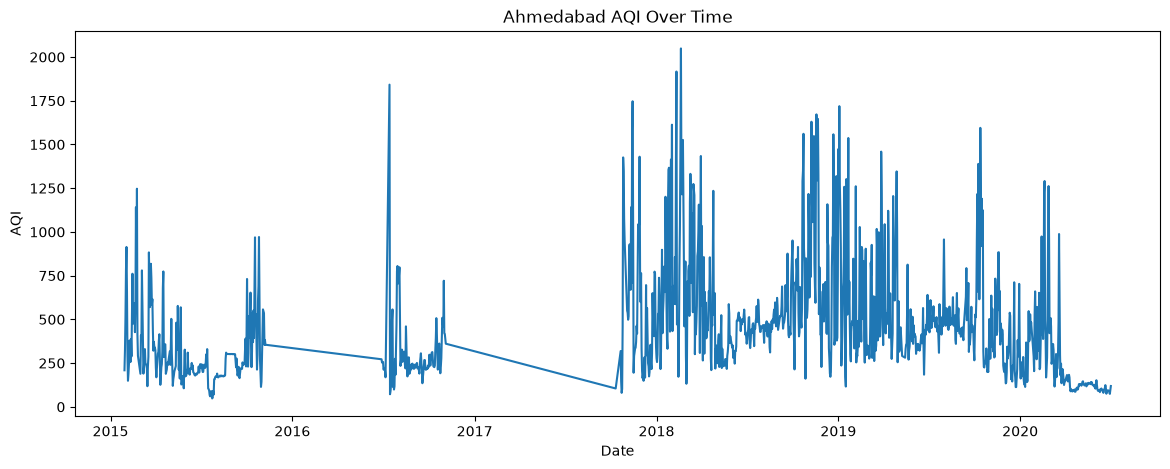

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(ahmedabad['AQI'])

plt.title('Ahmedabad AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')

plt.show()

In [92]:
import statsmodels
print(statsmodels.__version__)

0.15.0


In [94]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ahmedabad['AQI'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.243530365136245
p-value: 0.000555599551217345


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_37460\3881590982.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(ahmedabad['AQI'])


since 0.000556 < 0.05
reject null hypothesis of non stationary

Ahmedabad AQI time series is stationary, and differencing is not required.

In [95]:
split_index = int(len(ahmedabad) * 0.8)

train = ahmedabad['AQI'].iloc[:split_index]
test = ahmedabad['AQI'].iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 1067
Testing observations: 267

Training period:
2015-01-29 00:00:00 to 2019-09-30 00:00:00

Testing period:
2019-10-01 00:00:00 to 2020-07-01 00:00:00


In [96]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1,0,1)
model = ARIMA(train, order=(1, 0, 1))
arima_model = model.fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1067
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -7327.068
Date:                Sun, 13 Sep 2026   AIC                          14662.135
Time:                        00:43:53   BIC                          14682.026
Sample:                             0   HQIC                         14669.671
                               - 1067                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        486.6522     34.104     14.270      0.000     419.810     553.495
ar.L1          0.7101      0.027     26.639      0.000       0.658       0.762
ma.L1         -0.0825      0.031     -2.678      0.0

c:\AIR_QUALITY_INDEX\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\AIR_QUALITY_INDEX\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\AIR_QUALITY_INDEX\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


In [99]:
ahmedabad = df[df['City'] == 'Ahmedabad'].copy()

ahmedabad['Date'] = pd.to_datetime(ahmedabad['Date'])

ahmedabad = (
    ahmedabad[['Date', 'AQI']]
    .dropna(subset=['AQI'])
    .sort_values('Date')
)

ahmedabad = ahmedabad.set_index('Date')

# Set daily frequency
ahmedabad = ahmedabad.asfreq('D')

# Fill missing AQI dates
ahmedabad['AQI'] = ahmedabad['AQI'].interpolate()

print(ahmedabad.head())
print("Frequency:", ahmedabad.index.freq)

              AQI
Date             
2015-01-29  209.0
2015-01-30  328.0
2015-01-31  514.0
2015-02-01  782.0
2015-02-02  914.0
Frequency: <Day>


In [100]:
aqi_series = ahmedabad['AQI']

split_index = int(len(aqi_series) * 0.8)

train = aqi_series.iloc[:split_index]
test = aqi_series.iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 1584
Testing observations: 397


In [101]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1, 0, 1))
arima_model = model.fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1584
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -10533.744
Date:                Sun, 13 Sep 2026   AIC                          21075.488
Time:                        00:58:05   BIC                          21096.959
Sample:                    01-29-2015   HQIC                         21083.465
                         - 05-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        407.6660     34.584     11.788      0.000     339.883     475.449
ar.L1          0.7692      0.017     45.231      0.000       0.736       0.803
ma.L1         -0.0267      0.022     -1.242      0.2

In [102]:
forecast = arima_model.forecast(steps=len(test))

print("Number of forecasted values:", len(forecast))
print(forecast.head())

Number of forecasted values: 397
2019-06-01    374.387011
2019-06-02    382.066812
2019-06-03    387.974344
2019-06-04    392.518593
2019-06-05    396.014165
Freq: D, Name: predicted_mean, dtype: float64


In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_arima = mean_absolute_error(test, forecast)
mse_arima = mean_squared_error(test, forecast)
rmse_arima = mse_arima ** 0.5
r2_arima = r2_score(test, forecast)

print("ARIMA Results")
print("----------------------")
print("MAE :", mae_arima)
print("MSE :", mse_arima)
print("RMSE:", rmse_arima)
print("R²  :", r2_arima)

ARIMA Results
----------------------
MAE : 190.2985658616303
MSE : 62601.790024881586
RMSE: 250.20349722751996
R²  : -0.030476104426932826


Random Forest is clearly much better for your current AQI prediction setup.

In [104]:
from statsmodels.tsa.arima.model import ARIMA

orders = [
    (1, 0, 0),
    (0, 0, 1),
    (2, 0, 1)
]

for order in orders:
    model = ARIMA(train, order=order)
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=len(test))

    mae = mean_absolute_error(test, forecast)
    rmse = mean_squared_error(test, forecast) ** 0.5
    r2 = r2_score(test, forecast)

    print(f"ARIMA{order}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")
    print("-" * 30)

ARIMA(1, 0, 0)
MAE : 190.32
RMSE: 250.21
R²  : -0.0305
------------------------------
ARIMA(0, 0, 1)
MAE : 190.42
RMSE: 250.30
R²  : -0.0312
------------------------------


c:\AIR_QUALITY_INDEX\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\AIR_QUALITY_INDEX\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


ARIMA(2, 0, 1)
MAE : 190.37
RMSE: 250.22
R²  : -0.0306
------------------------------


ARIMA FORECAST PLOT

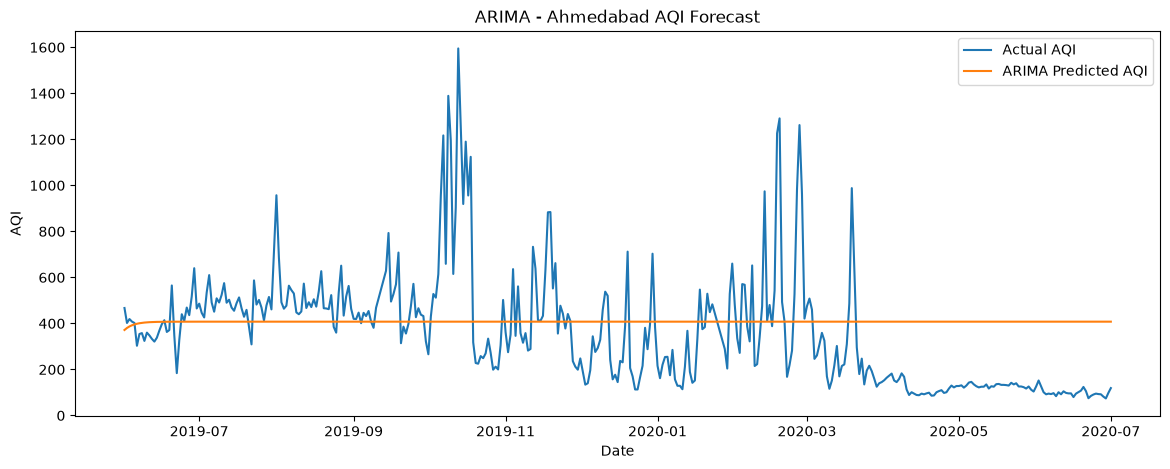

In [105]:
# Fit the selected ARIMA model
best_arima = ARIMA(train, order=(1, 0, 0)).fit()

# Forecast test period
arima_forecast = best_arima.forecast(steps=len(test))

# Plot actual vs predicted
plt.figure(figsize=(14, 5))

plt.plot(test.index, test, label='Actual AQI')
plt.plot(test.index, arima_forecast, label='ARIMA Predicted AQI')

plt.title('ARIMA - Ahmedabad AQI Forecast')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()

In [106]:
import mlflow

mlflow.sklearn.autolog(disable=True)

In [107]:
#log arima experiment
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow

with mlflow.start_run(run_name="ARIMA Ahmedabad AQI"):

    # Train ARIMA
    model = ARIMA(train, order=(1, 0, 0))
    arima_model = model.fit()

    # Forecast
    forecast = arima_model.forecast(steps=len(test))

    # Evaluation
    mae = mean_absolute_error(test, forecast)
    mse = mean_squared_error(test, forecast)
    rmse = mean_squared_error(test, forecast) ** 0.5
    r2 = r2_score(test, forecast)

    # Log metrics
    mlflow.log_metric("test_MAE", mae)
    mlflow.log_metric("test_MSE", mse)
    mlflow.log_metric("test_RMSE", rmse)
    mlflow.log_metric("test_R2", r2)

    # Log ARIMA parameters
    mlflow.log_param("model", "ARIMA")
    mlflow.log_param("city", "Ahmedabad")
    mlflow.log_param("p", 1)
    mlflow.log_param("d", 0)
    mlflow.log_param("q", 0)

    # Additional information
    mlflow.set_tag("feature_type", "Historical AQI")
    mlflow.set_tag("experiment_type", "Time Series Forecasting")
    mlflow.set_tag("dataset", "Air Quality Data in India")

    print("ARIMA Results")
    print("----------------------")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

print("ARIMA experiment logged successfully!")

ARIMA Results
----------------------
MAE : 190.31783752453222
MSE : 62603.87117083654
RMSE: 250.20765609956172
R²  : -0.030510361772857708
ARIMA experiment logged successfully!


In [108]:
runs = mlflow.search_runs(
    experiment_names=["AQI Prediction - ML Experiments"]
)

runs[[
    "run_id",
    "tags.mlflow.runName",
    "params.model",
    "params.city",
    "params.p",
    "params.d",
    "params.q",
    "metrics.test_MAE",
    "metrics.test_RMSE",
    "metrics.test_R2"
]]

,run_id,tags.mlflow.runName,params.model,params.city,params.p,params.d,params.q,metrics.test_MAE,metrics.test_RMSE,metrics.test_R2
0,b8001be315944473bc5beafb33b8f32a,ARIMA Ahmedabad AQI,ARIMA,Ahmedabad,1,0,0,190.317838,250.207656,-0.030510
1,a6a59ce85243446098b9e7ec80740b8f,Random Forest + City - Test Evaluation,NaN,NaN,NaN,NaN,NaN,20.434469,40.373586,0.910981
2,68c415913b4444518e3df51e7df2b234,Random Forest + City,"RandomForestRegressor(n_jobs=-1, random_state=42)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,52f5d380195f42fc8b23eea465448d57,Random Forest + City - Test Evaluation,NaN,NaN,NaN,NaN,NaN,20.434469,40.373586,0.910981
4,033a469f08db4099a4ca929cf5669783,Random Forest + City,"RandomForestRegressor(n_jobs=-1, random_state=42)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,725cdefc8f2147f68e4b41e82dc58e6c,Random Forest + City,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


final MLflow comparison table

In [109]:
final_runs = mlflow.search_runs(
    experiment_names=["AQI Prediction - ML Experiments"]
)

final_runs = final_runs[
    final_runs["tags.mlflow.runName"].isin([
        "ARIMA Ahmedabad AQI",
        "Random Forest + City - Test Evaluation"
    ])
]

final_runs[[
    "tags.mlflow.runName",
    "metrics.test_MAE",
    "metrics.test_RMSE",
    "metrics.test_R2"
]]

,tags.mlflow.runName,metrics.test_MAE,metrics.test_RMSE,metrics.test_R2
0,ARIMA Ahmedabad AQI,190.317838,250.207656,-0.030510
1,Random Forest + City - Test Evaluation,20.434469,40.373586,0.910981
3,Random Forest + City - Test Evaluation,20.434469,40.373586,0.910981


In [111]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib

# Remove rows where the target AQI is missing
df_model = df.dropna(subset=['AQI']).copy()

# Features and target
X = df_model.drop(columns=['AQI'])
y = df_model['AQI']

print("Rows before removing missing AQI:", len(df))
print("Rows after removing missing AQI:", len(df_model))
print("Missing AQI:", y.isna().sum())

Rows before removing missing AQI: 29531
Rows after removing missing AQI: 24850
Missing AQI: 0


In [112]:
categorical_features = ['City']

numerical_features = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features)])

final_rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1))
    ]
)

final_rf_pipeline.fit(X, y)

print("Final Random Forest pipeline trained successfully!")

Final Random Forest pipeline trained successfully!


In [113]:
joblib.dump(
    final_rf_pipeline,
    'final_aqi_rf_pipeline.pkl'
)

print("Model saved as: final_aqi_rf_pipeline.pkl")

Model saved as: final_aqi_rf_pipeline.pkl


In [114]:
loaded_model = joblib.load('final_aqi_rf_pipeline.pkl')

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>
